Plus family (p > p*):
p*		γ		R²
--------------------------------------------------
4.108		0.79553		0.994000
4.109		0.68585		0.994648
4.11		0.57336		0.994229
4.111		0.45555		0.990425
4.112		0.32468		0.972829

Result: γ = 0.57336 ± 0.16585
R² (minimum): 0.972829


Minus family (p < p*):
p*		γ		R²
--------------------------------------------------
4.108		0.32468		0.972829
4.109		0.45555		0.990425
4.11		0.57336		0.994229
4.111		0.68585		0.994648
4.112		0.79553		0.994000

Result: γ = 0.57336 ± 0.16585
R² (minimum): 0.972829


FINAL RESULTS:
Plus family:  γ = 0.57336 ± 0.16585, R² ≥ 0.9728
Minus family: γ = 0.57336 ± 0.16585, R² ≥ 0.9728


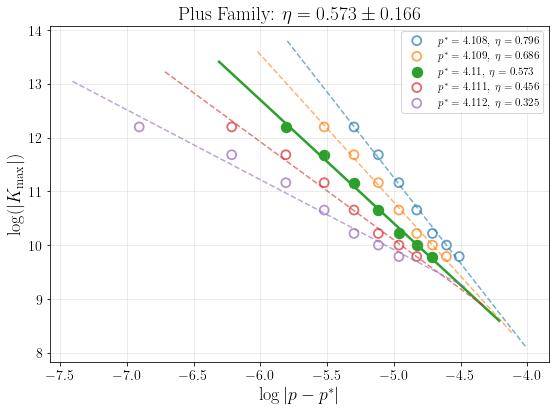

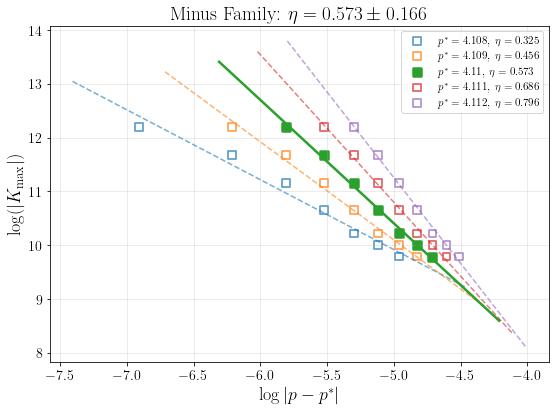

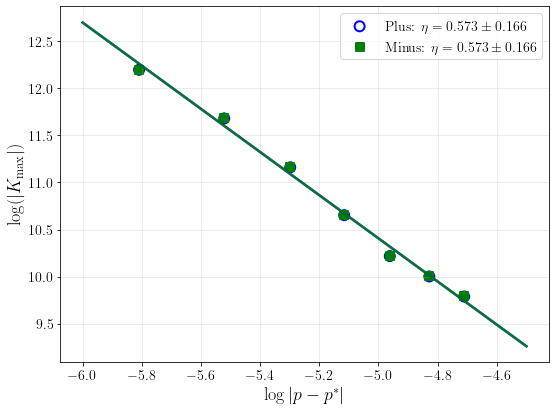


SAVED FILES:
1. scaling_plus_family.pdf   - Plus family with all p* values
2. scaling_minus_family.pdf  - Minus family with all p* values
3. scaling_combined_central.pdf - Both families (central p* only)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12
})

# ---------------------------
# DATA
# ---------------------------
curvature_plus = np.array([
    17826.42451, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036, 118249.5124607959,
    198236.4599101593
])

p_plus = np.array([4.119, 4.118, 4.117, 4.116, 4.115, 4.114, 4.113])

curvature_minus = np.array([
    17826.6541, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036,
    118249.5124607959, 198236.4599101593
])

p_minus = np.array([4.101, 4.102, 4.103, 4.104, 4.105, 4.106, 4.107])

# ---------------------------
# FUNCTION
# ---------------------------
def compute_gamma_with_r2(p_values, curvature, p_star):
    delta = p_values - p_star
    delta_abs = np.abs(delta)
    x = np.log(delta_abs)
    y = np.log(curvature)
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    
    y_pred = slope * x + intercept
    r_squared = pearsonr(y, y_pred)[0]**2
    
    return gamma, slope, intercept, r_squared, x, y

# ---------------------------
# SCAN P* VALUES
# ---------------------------
pstar_values = [4.108, 4.109, 4.110, 4.111, 4.112]

# Color map for different p* values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

print("Plus family (p > p*):")
print("p*\t\tγ\t\tR²")
print("-" * 50)
gammas_plus = []
r2_plus = []
results_plus = []

for i, pstar in enumerate(pstar_values):
    gamma, slope, intercept, r2, x, y = compute_gamma_with_r2(p_plus, curvature_plus, pstar)
    gammas_plus.append(gamma)
    r2_plus.append(r2)
    results_plus.append((gamma, slope, intercept, r2, x, y))
    print(f"{pstar}\t\t{gamma:.5f}\t\t{r2:.6f}")

gamma_plus_central = gammas_plus[2]
gamma_plus_err = np.std(gammas_plus)
r2_plus_min = np.min(r2_plus)

print(f"\nResult: γ = {gamma_plus_central:.5f} ± {gamma_plus_err:.5f}")
print(f"R² (minimum): {r2_plus_min:.6f}")

print("\n" + "="*50)
print("\nMinus family (p < p*):")
print("p*\t\tγ\t\tR²")
print("-" * 50)
gammas_minus = []
r2_minus = []
results_minus = []

for i, pstar in enumerate(pstar_values):
    gamma, slope, intercept, r2, x, y = compute_gamma_with_r2(p_minus, curvature_minus, pstar)
    gammas_minus.append(gamma)
    r2_minus.append(r2)
    results_minus.append((gamma, slope, intercept, r2, x, y))
    print(f"{pstar}\t\t{gamma:.5f}\t\t{r2:.6f}")

gamma_minus_central = gammas_minus[2]
gamma_minus_err = np.std(gammas_minus)
r2_minus_min = np.min(r2_minus)

print(f"\nResult: γ = {gamma_minus_central:.5f} ± {gamma_minus_err:.5f}")
print(f"R² (minimum): {r2_minus_min:.6f}")

print("\n" + "="*50)
print("\nFINAL RESULTS:")
print("="*50)
print(f"Plus family:  γ = {gamma_plus_central:.5f} ± {gamma_plus_err:.5f}, R² ≥ {r2_plus_min:.4f}")
print(f"Minus family: γ = {gamma_minus_central:.5f} ± {gamma_minus_err:.5f}, R² ≥ {r2_minus_min:.4f}")

# ---------------------------
# PLOT 1: PLUS FAMILY
# ---------------------------
fig1, ax1 = plt.subplots(1, 1, figsize=(8, 6))

for i, (gamma, slope, intercept, r2, x, y) in enumerate(results_plus):
    pstar = pstar_values[i]
    color = colors[i]
    
    # Scatter points
    ax1.scatter(x, y, marker='o', s=80, 
                facecolors='none' if i != 2 else color,
                edgecolors=color, linewidth=1.8 if i != 2 else 2.5,
                alpha=0.7 if i != 2 else 1.0,
                label=f"$p^*={pstar}$, $\\eta={gamma:.3f}$")
    
    # Fit line
    x_fit = np.linspace(x.min() - 0.5, x.max() + 0.5, 100)
    ax1.plot(x_fit, slope*x_fit + intercept, 
             linestyle='--' if i != 2 else '-',
             linewidth=1.5 if i != 2 else 2.5,
             color=color, alpha=0.6 if i != 2 else 1.0)

ax1.set_xlabel(r"$\log|p - p^*|$")
ax1.set_ylabel(r"$\log(|K_{\max}|)$")
ax1.set_title(f"Plus Family: $\\eta = {gamma_plus_central:.3f} \\pm {gamma_plus_err:.3f}$")
ax1.legend(fontsize=11, loc='best')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("scaling_plus_family.png", dpi=300)
plt.show()

# ---------------------------
# PLOT 2: MINUS FAMILY
# ---------------------------
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 6))

for i, (gamma, slope, intercept, r2, x, y) in enumerate(results_minus):
    pstar = pstar_values[i]
    color = colors[i]
    
    # Scatter points
    ax2.scatter(x, y, marker='s', s=60,
                facecolors=color if i == 2 else 'none',
                edgecolors=color, linewidth=1.8 if i != 2 else 2.5,
                alpha=0.7 if i != 2 else 1.0,
                label=f"$p^*={pstar}$, $\\eta={gamma:.3f}$")
    
    # Fit line
    x_fit = np.linspace(x.min() - 0.5, x.max() + 0.5, 100)
    ax2.plot(x_fit, slope*x_fit + intercept,
             linestyle='--' if i != 2 else '-',
             linewidth=1.5 if i != 2 else 2.5,
             color=color, alpha=0.6 if i != 2 else 1.0)

ax2.set_xlabel(r"$\log|p - p^*|$")
ax2.set_ylabel(r"$\log(|K_{\max}|)$")
ax2.set_title(f"Minus Family: $\\eta = {gamma_minus_central:.3f} \\pm {gamma_minus_err:.3f}$")
ax2.legend(fontsize=11, loc='best')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("scaling_minus_family.pdf", dpi=300)
plt.show()

# ---------------------------
# PLOT 3: COMBINED (CENTRAL VALUES ONLY)
# ---------------------------
fig3, ax3 = plt.subplots(1, 1, figsize=(8, 6))

# Plus family - central
gamma, slope, intercept, r2, x, y = results_plus[2]
ax3.scatter(x, y, marker='o', s=100, 
           facecolors='none', edgecolors='blue', linewidth=2,
           label=f"Plus: $\\eta={gamma_plus_central:.3f} \\pm {gamma_plus_err:.3f}$")
x_fit = np.linspace(-6, -4.5, 100)
ax3.plot(x_fit, slope*x_fit + intercept, '-', linewidth=2.5, color='blue', alpha=0.8)

# Minus family - central
gamma, slope, intercept, r2, x, y = results_minus[2]
ax3.scatter(x, y, marker='s', s=70,
           facecolors='green', edgecolors='green', linewidth=2,
           label=f"Minus: $\\eta={gamma_minus_central:.3f} \\pm {gamma_minus_err:.3f}$")
x_fit = np.linspace(-6, -4.5, 100)
ax3.plot(x_fit, slope*x_fit + intercept, '-', linewidth=2.5, color='green', alpha=0.8)

ax3.set_xlabel(r"$\log|p - p^*|$")
ax3.set_ylabel(r"$\log(|K_{\max}|)$")
ax3.legend(fontsize=14)
ax3.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("scaling_combined_central.pdf", dpi=300)
plt.show()

print("\n" + "="*50)
print("SAVED FILES:")
print("="*50)
print("1. scaling_plus_family.pdf   - Plus family with all p* values")
print("2. scaling_minus_family.pdf  - Minus family with all p* values")
print("3. scaling_combined_central.pdf - Both families (central p* only)")